<h1 style='color:green'>Linear Regression</h1>

#### Linear Regression is a statistical supervised learning technique to predict the quantitative variable by forming a linear relationship with one or more independent features

- Linear Regression
- Error Function
- Gradient Descent
- Implementation

### Regression predicts a continuous value

<h2 style='color:blue'>Before drive to code, we understand some basic</h2>

[View the PDF](./002-Linear-Regression.pdf)

In [3]:
from IPython.display import IFrame
IFrame("002-Linear-Regression.pdf", width=1000, height=600)

<h1 style='color:Red'>Gradient Descent (In General)</h1>

In [16]:
import numpy as np 
import matplotlib.pyplot as plt

In [22]:
#Generate data using dummy function 
X = np.arange(10) 
Y = (X-5)**2 + 3 

print(X,Y)

[0 1 2 3 4 5 6 7 8 9] [28 19 12  7  4  3  4  7 12 19]


In [26]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


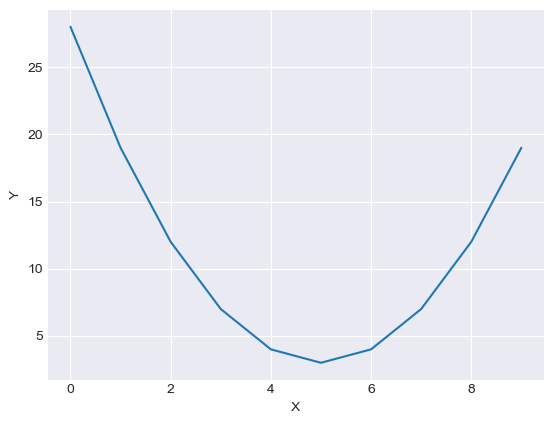

In [34]:
#Visualise 
plt.style.use('seaborn-v0_8-darkgrid')
plt.plot(X,Y)
plt.ylabel('Y')
plt.xlabel('X')
plt.show()

1.0
1.8
2.4400000000000004
2.9520000000000004
3.3616
3.68928
3.9514240000000003
4.1611392
4.32891136
4.4631290880000005
4.570503270400001
4.65640261632
4.725122093056
4.7800976744448
4.82407813955584
4.859262511644672
4.8874100093157375
4.90992800745259
4.927942405962073
4.942353924769658
4.953883139815726
4.9631065118525814
4.9704852094820655
4.976388167585652
4.981110534068522
4.984888427254818
4.987910741803854
4.990328593443083
4.992262874754466
4.993810299803573
4.995048239842858
4.996038591874287
4.996830873499429
4.9974646987995435
4.997971759039634
4.9983774072317075
4.998701925785366
4.998961540628293
4.999169232502634
4.999335386002107
4.999468308801686
4.9995746470413485
4.999659717633079
4.9997277741064625
4.99978221928517
4.999825775428136
4.999860620342509
4.999888496274007
4.999910797019206
4.999928637615365


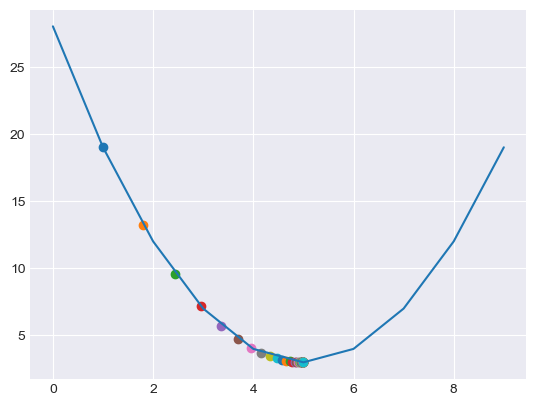

In [42]:
#Gradient Descent 
x = 0 #init x with any random value 
lr = 0.1 

plt.plot(X,Y)
for i in range(50): 
    grad = 2*(x-5)  # y = (x-5)**2 + 3  so, dy/dx = 2*(x-5) + 0
    x = x - lr*grad 
    y = (x-5)**2 + 3
    plt.scatter(x,y)
    print(x)

plt.show()

8.2
7.56
7.048
6.6384
6.31072
6.048576
5.8388608
5.67108864
5.5368709119999995
5.429496729599999
5.34359738368
5.274877906944
5.2199023255552
5.17592186044416
5.140737488355328
5.1125899906842625
5.09007199254741
5.072057594037927
5.057646075230342
5.046116860184274
5.0368934881474186
5.0295147905179345
5.023611832414348
5.018889465931478
5.015111572745182
5.012089258196146
5.009671406556917
5.007737125245534
5.006189700196427
5.004951760157142
5.003961408125713
5.003169126500571
5.0025353012004565
5.002028240960366
5.0016225927682925
5.001298074214634
5.001038459371707
5.000830767497366
5.000664613997893
5.000531691198314
5.0004253529586515
5.000340282366921
5.0002722258935375
5.00021778071483
5.000174224571864
5.000139379657491
5.000111503725993
5.000089202980794
5.000071362384635
5.000057089907708


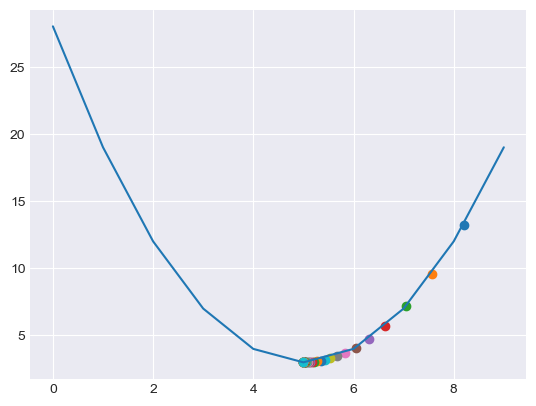

In [44]:
# We can also start from x = 9 
x = 9
lr = 0.1 

plt.plot(X,Y)
for i in range(50): 
    grad = 2*(x-5)  # y = (x-5)**2 + 3  so, dy/dx = 2*(x-5) + 0
    x = x - lr*grad 
    y = (x-5)**2 + 3
    plt.scatter(x,y)
    print(x)

plt.show()

# Let's code for Linear Regression 

In [49]:
import numpy as np 
import matplotlib.pyplot as plt 
plt.style.use("seaborn-v0_8-darkgrid")

In [25]:
#Data Generation 
def generateDataset(m):
    X = np.random.randn(m)*10 
    noise = np.random.randn(m) 
    y = 3*X + 1 + noise*5
    return X,y


In [27]:
X, y = generateDataset(100)

In [53]:
def plotData(X,y,color='orange',title='Data'):
    plt.title(title)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.scatter(X,y,c=color)
    plt.show()

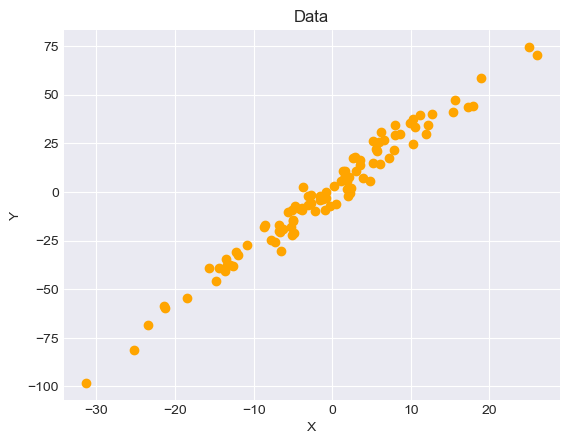

In [55]:
plotData(X,y)

### Formula for standardization  
### x = (x - x.mean())/x.std()

In [65]:
def normaliseData(X): 
    X = (X-X.mean())/X.std()
    return X 

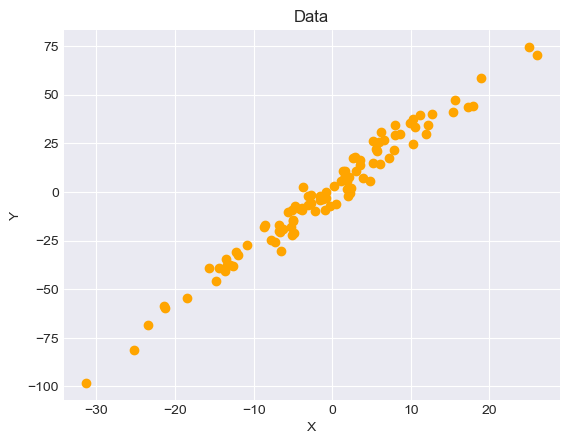

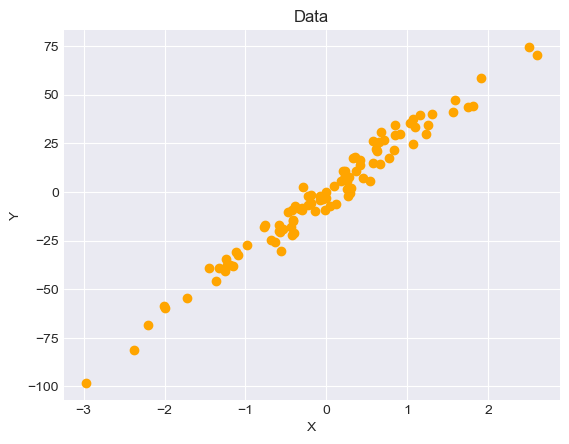

In [69]:
plotData(X,y)
X = normaliseData(X) # most of the data between -1 to 1
plotData(X,y)

In [71]:
#Train Test split 
def trainTestSplit(X,y, split=0.8): 
    m = X.shape[0]
    data = np.zeros((m,2))

    data[:,0] = X 
    data[:,1] = y 

    np.random.shuffle(data) 

    split = int(m*split) 

    XT = data[:split, 0] 
    yT = data[:split, 1] 

    Xt = data[split:, 0] 
    yt = data[split:, 1]

    return XT, yT, Xt, yt 

In [73]:
XT, yT, Xt, yt = trainTestSplit(X,y)

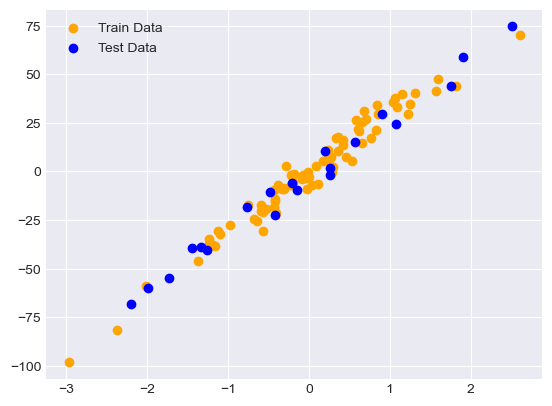

In [80]:
plt.scatter(XT,yT,color='orange', label='Train Data')
plt.scatter(Xt,yt,color='blue', label='Test Data')
plt.legend()
plt.show()

## Modeling

In [99]:
#Hypothesis 
def hypothesis(X, theta): 
    return theta[0] + theta[1]*X

def error(x,y,theta):
    m = X.shape[0]
    e = 0 
    for i in range(m): 
        y_i = hypothesis(X[i], theta) 
        e = e + (y[i] - y_i)**2 
    return e/(2*m)

def gradient(X,y,theta): 
    m = X.shape[0]
    grad = np.zeros((2,))

    for i in range(m): 
        exp = hypothesis(X[i],theta) - y[i] 
        grad[0] += (exp)
        grad[1] += (exp)*X[i]

    return grad/m

def train(X, y, lr=0.1, maxItrs = 100): 
    theta = np.zeros((2,))

    error_list = []
    
    for i in range(maxItrs): 
        grad = gradient(X,y,theta)
        error_list.append(error(X,y,theta))
        theta[0] = theta[0] - lr*grad[0]
        theta[1] = theta[1] - lr*grad[1]

    plt.xlabel("Iteration Number")
    plt.ylabel("Loss")
    plt.plot(error_list)
    return theta

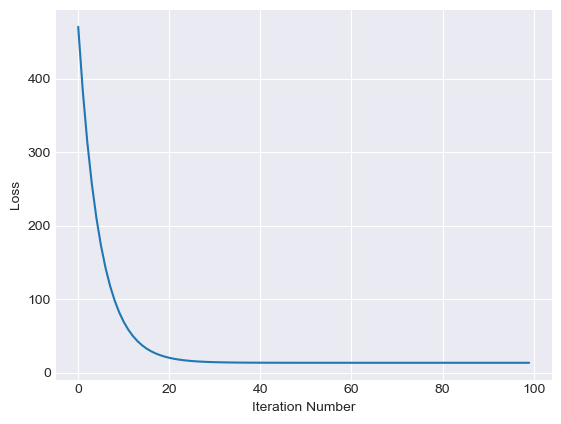

In [101]:
theta = train(X,y)

In [103]:
theta

array([-1.03774498, 30.22187536])

In [105]:
def predict(X, theta): 
    return hypothesis(X, theta)

In [111]:
yp = predict(Xt, theta)

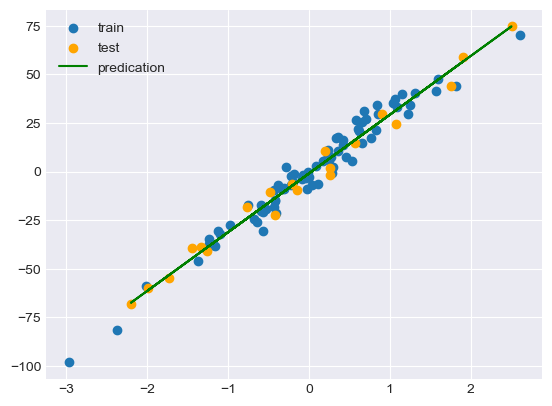

In [115]:
plt.scatter(XT, yT, label='train')
plt.scatter(Xt, yt, color='orange', label='test')
plt.plot(Xt, yp, color='green', label='predication')
plt.legend()
plt.show()

# R2 Score  
#### Coefficient of determination is a statistical measure of how well the regression predictions approximate the real data points
<h3 style='color:green'>An R2 of 1 indicates that the regression predictions perfectly fit the dat</h3>

<img src='R2Score.png'>

## Evaluation

In [125]:
#Model Evaluation 
def r2Score(y, yp): 
    T1 = np.sum((y-yp)**2)
    T2 = np.sum((y-y.mean())**2)
    return 1 - T1/T2 

In [127]:
r2Score(yt,yp)

0.984142650157013